# Práctica Final - Machine Learning y Ciberseguridad

Vamos a intentar predecir qué acción se toma cuando hay un ciberataque 
(la columna "Action Taken") usando un dataset con 40.000 incidencias. 
Es un problema de clasificación supervisada

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/cybersecurity_attacks.csv')
print(df.shape)
df.head().T

(40000, 25)


,0,1,2,3,4
Timestamp,2023-05-30 06:33:58,2020-08-26 07:08:30,2022-11-13 08:23:25,2023-07-02 10:38:46,2023-07-16 13:11:07
Source IP Address,103.216.15.12,78.199.217.198,63.79.210.48,163.42.196.10,71.166.185.76
Destination IP Address,84.9.164.252,66.191.137.154,198.219.82.17,101.228.192.255,189.243.174.238
Source Port,31225,17245,16811,20018,6131
Destination Port,17616,48166,53600,32534,26646
Protocol,ICMP,ICMP,UDP,UDP,TCP
Packet Length,503,1174,306,385,1462
Packet Type,Data,Data,Control,Data,Data
Traffic Type,HTTP,HTTP,HTTP,HTTP,DNS
Payload Data,Qui natus odio asperiores nam. Optio nobis ius...,Aperiam quos modi officiis veritatis rem. Omni...,Perferendis sapiente vitae soluta. Hic delectu...,Totam maxime beatae expedita explicabo porro l...,Odit nesciunt dolorem nisi iste iusto. Animi v...


In [3]:
df.dtypes

Timestamp                  object
Source IP Address          object
Destination IP Address     object
Source Port                 int64
Destination Port            int64
Protocol                   object
Packet Length               int64
Packet Type                object
Traffic Type               object
Payload Data               object
Malware Indicators         object
Anomaly Scores            float64
Alerts/Warnings            object
Attack Type                object
Attack Signature           object
Action Taken               object
Severity Level             object
User Information           object
Device Information         object
Network Segment            object
Geo-location Data          object
Proxy Information          object
Firewall Logs              object
IDS/IPS Alerts             object
Log Source                 object
dtype: object

In [4]:
df.describe()

,Source Port,Destination Port,Packet Length,Anomaly Scores
count,40000.000000,40000.000000,40000.000000,40000.000000
mean,32970.356450,33150.868650,781.452725,50.113473
std,18560.425604,18574.668842,416.044192,28.853598
min,1027.000000,1024.000000,64.000000,0.000000
25%,16850.750000,17094.750000,420.000000,25.150000
50%,32856.000000,33004.500000,782.000000,50.345000
75%,48928.250000,49287.000000,1143.000000,75.030000
max,65530.000000,65535.000000,1500.000000,100.000000


In [5]:
df.describe(include='all')

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
count,40000,40000,40000,40000.000000,40000.000000,40000,40000.000000,40000,40000,40000,...,40000,40000,40000,40000,40000,40000,20149,20039,19950,40000
unique,39997,40000,40000,NaN,NaN,3,NaN,2,3,40000,...,3,3,32389,32104,3,8723,20148,1,1,2
top,2022-06-11 14:28:15,103.216.15.12,84.9.164.252,NaN,NaN,ICMP,NaN,Control,DNS,Qui natus odio asperiores nam. Optio nobis ius...,...,Blocked,Medium,Ishaan Chaudhari,Mozilla/5.0 (compatible; MSIE 6.0; Windows NT ...,Segment C,"Ghaziabad, Meghalaya",39.123.165.122,Log Data,Alert Data,Firewall
freq,2,1,1,NaN,NaN,13429,NaN,20237,13376,1,...,13529,13435,6,35,13408,16,2,20039,19950,20116
mean,NaN,NaN,NaN,32970.356450,33150.868650,NaN,781.452725,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,18560.425604,18574.668842,NaN,416.044192,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,1027.000000,1024.000000,NaN,64.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,16850.750000,17094.750000,NaN,420.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,32856.000000,33004.500000,NaN,782.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,48928.250000,49287.000000,NaN,1143.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.isnull().any()

Timestamp                 False
Source IP Address         False
Destination IP Address    False
Source Port               False
Destination Port          False
Protocol                  False
Packet Length             False
Packet Type               False
Traffic Type              False
Payload Data              False
Malware Indicators         True
Anomaly Scores            False
Alerts/Warnings            True
Attack Type               False
Attack Signature          False
Action Taken              False
Severity Level            False
User Information          False
Device Information        False
Network Segment           False
Geo-location Data         False
Proxy Information          True
Firewall Logs              True
IDS/IPS Alerts             True
Log Source                False
dtype: bool

In [7]:
df['Action Taken'].value_counts()

Action Taken
Blocked    13529
Ignored    13276
Logged     13195
Name: count, dtype: int64

Solo hay 4 columnas numéricas (Source Port, Destination Port, Packet Length, 
Anomaly Scores), el resto es todo texto. Hay 5 columnas con valores nulos: 
Malware Indicators, Alerts/Warnings, Proxy Information, Firewall Logs e 
IDS/IPS Alerts. Las tres clases de Action Taken están muy equilibradas, 
unas 13.300 muestras cada una, así que podemos usar accuracy como métrica.

## 2. Outliers y correlación

Miro si hay valores raros en las columnas numéricas con un boxplot y 
también miro la correlación entre ellas para ver si hay alguna relación.

In [8]:
df.describe()

,Source Port,Destination Port,Packet Length,Anomaly Scores
count,40000.000000,40000.000000,40000.000000,40000.000000
mean,32970.356450,33150.868650,781.452725,50.113473
std,18560.425604,18574.668842,416.044192,28.853598
min,1027.000000,1024.000000,64.000000,0.000000
25%,16850.750000,17094.750000,420.000000,25.150000
50%,32856.000000,33004.500000,782.000000,50.345000
75%,48928.250000,49287.000000,1143.000000,75.030000
max,65530.000000,65535.000000,1500.000000,100.000000


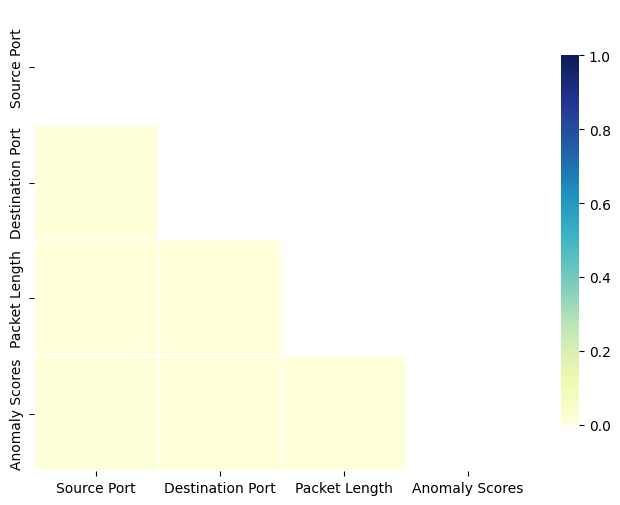

In [9]:
corr = np.abs(df.drop(['Action Taken'], axis=1).select_dtypes(include=[np.number]).corr())

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, vmin=0.0, vmax=1.0, center=0.5,
            linewidths=.1, cmap="YlGnBu", cbar_kws={"shrink": .8})
plt.show()

No se detectan outliers en las columnas numéricas, los valores están dentro de 
rangos normales para datos de red (puertos entre 1024-65535, tamaño de paquete 
entre 64-1500 bytes, anomaly score entre 0-100). La correlación entre las columnas 
numéricas es prácticamente cero, no hay relación lineal entre ellas.

## 3. Preprocesamiento

Ahora toca preparar los datos. Primero elimino las columnas que no sirven: las que 
tienen miles de valores únicos (IPs, timestamps, texto del payload, nombres de usuario, 
device info, geolocalización) porque un modelo no puede aprender nada de ellas. 
También elimino Proxy Information, Firewall Logs e IDS/IPS Alerts porque tienen 
casi la mitad de valores vacíos. Las columnas Malware Indicators y Alerts/Warnings 
también tienen nulos pero las convierto en 0 y 1 (tiene valor o no tiene).

In [10]:
columns_to_drop = ['Timestamp', 'Source IP Address', 'Destination IP Address',
                   'Payload Data', 'User Information', 'Device Information',
                   'Geo-location Data', 'Proxy Information', 'Firewall Logs',
                   'IDS/IPS Alerts']

df = df.drop(columns_to_drop, axis=1)

df['Malware Indicators'] = df['Malware Indicators'].apply(lambda x: 0 if pd.isnull(x) else 1)
df['Alerts/Warnings'] = df['Alerts/Warnings'].apply(lambda x: 0 if pd.isnull(x) else 1)

df.head().T

,0,1,2,3,4
Source Port,31225,17245,16811,20018,6131
Destination Port,17616,48166,53600,32534,26646
Protocol,ICMP,ICMP,UDP,UDP,TCP
Packet Length,503,1174,306,385,1462
Packet Type,Data,Data,Control,Data,Data
Traffic Type,HTTP,HTTP,HTTP,HTTP,DNS
Malware Indicators,1,1,1,0,0
Anomaly Scores,28.67,51.5,87.42,15.79,0.52
Alerts/Warnings,0,0,1,1,1
Attack Type,Malware,Malware,DDoS,Malware,DDoS


Ahora codifico las columnas de texto a números con LabelEncoder, que es lo que 
usamos en clase. Creo un encoder para cada columna para saber qué número 
corresponde a qué valor.

In [11]:
from sklearn.preprocessing import LabelEncoder

le_protocol = LabelEncoder()
le_packet = LabelEncoder()
le_traffic = LabelEncoder()
le_attack = LabelEncoder()
le_severity = LabelEncoder()
le_network = LabelEncoder()
le_action = LabelEncoder()
le_signature = LabelEncoder()
le_log = LabelEncoder()

df['Protocol'] = le_protocol.fit_transform(df['Protocol'])
df['Packet Type'] = le_packet.fit_transform(df['Packet Type'])
df['Traffic Type'] = le_traffic.fit_transform(df['Traffic Type'])
df['Attack Type'] = le_attack.fit_transform(df['Attack Type'])
df['Severity Level'] = le_severity.fit_transform(df['Severity Level'])
df['Network Segment'] = le_network.fit_transform(df['Network Segment'])
df['Action Taken'] = le_action.fit_transform(df['Action Taken'])
df['Attack Signature'] = le_signature.fit_transform(df['Attack Signature'])
df['Log Source'] = le_log.fit_transform(df['Log Source'])

print(list(le_action.classes_))
df.head().T

['Blocked', 'Ignored', 'Logged']


,0,1,2,3,4
Source Port,31225.00,17245.0,16811.00,20018.00,6131.00
Destination Port,17616.00,48166.0,53600.00,32534.00,26646.00
Protocol,0.00,0.0,2.00,2.00,1.00
Packet Length,503.00,1174.0,306.00,385.00,1462.00
Packet Type,1.00,1.0,0.00,1.00,1.00
Traffic Type,2.00,2.0,2.00,2.00,0.00
Malware Indicators,1.00,1.0,1.00,0.00,0.00
Anomaly Scores,28.67,51.5,87.42,15.79,0.52
Alerts/Warnings,0.00,0.0,1.00,1.00,1.00
Attack Type,2.00,2.0,0.00,2.00,0.00


## 4. Histogramas por clase

Pinto los histogramas de cada columna separados por las tres clases de Action Taken 
para ver si alguna columna sirve para distinguir entre Blocked, Ignored y Logged. 
Si las tres clases se solapan en una columna significa que esa columna no aporta 
información útil para predecir.

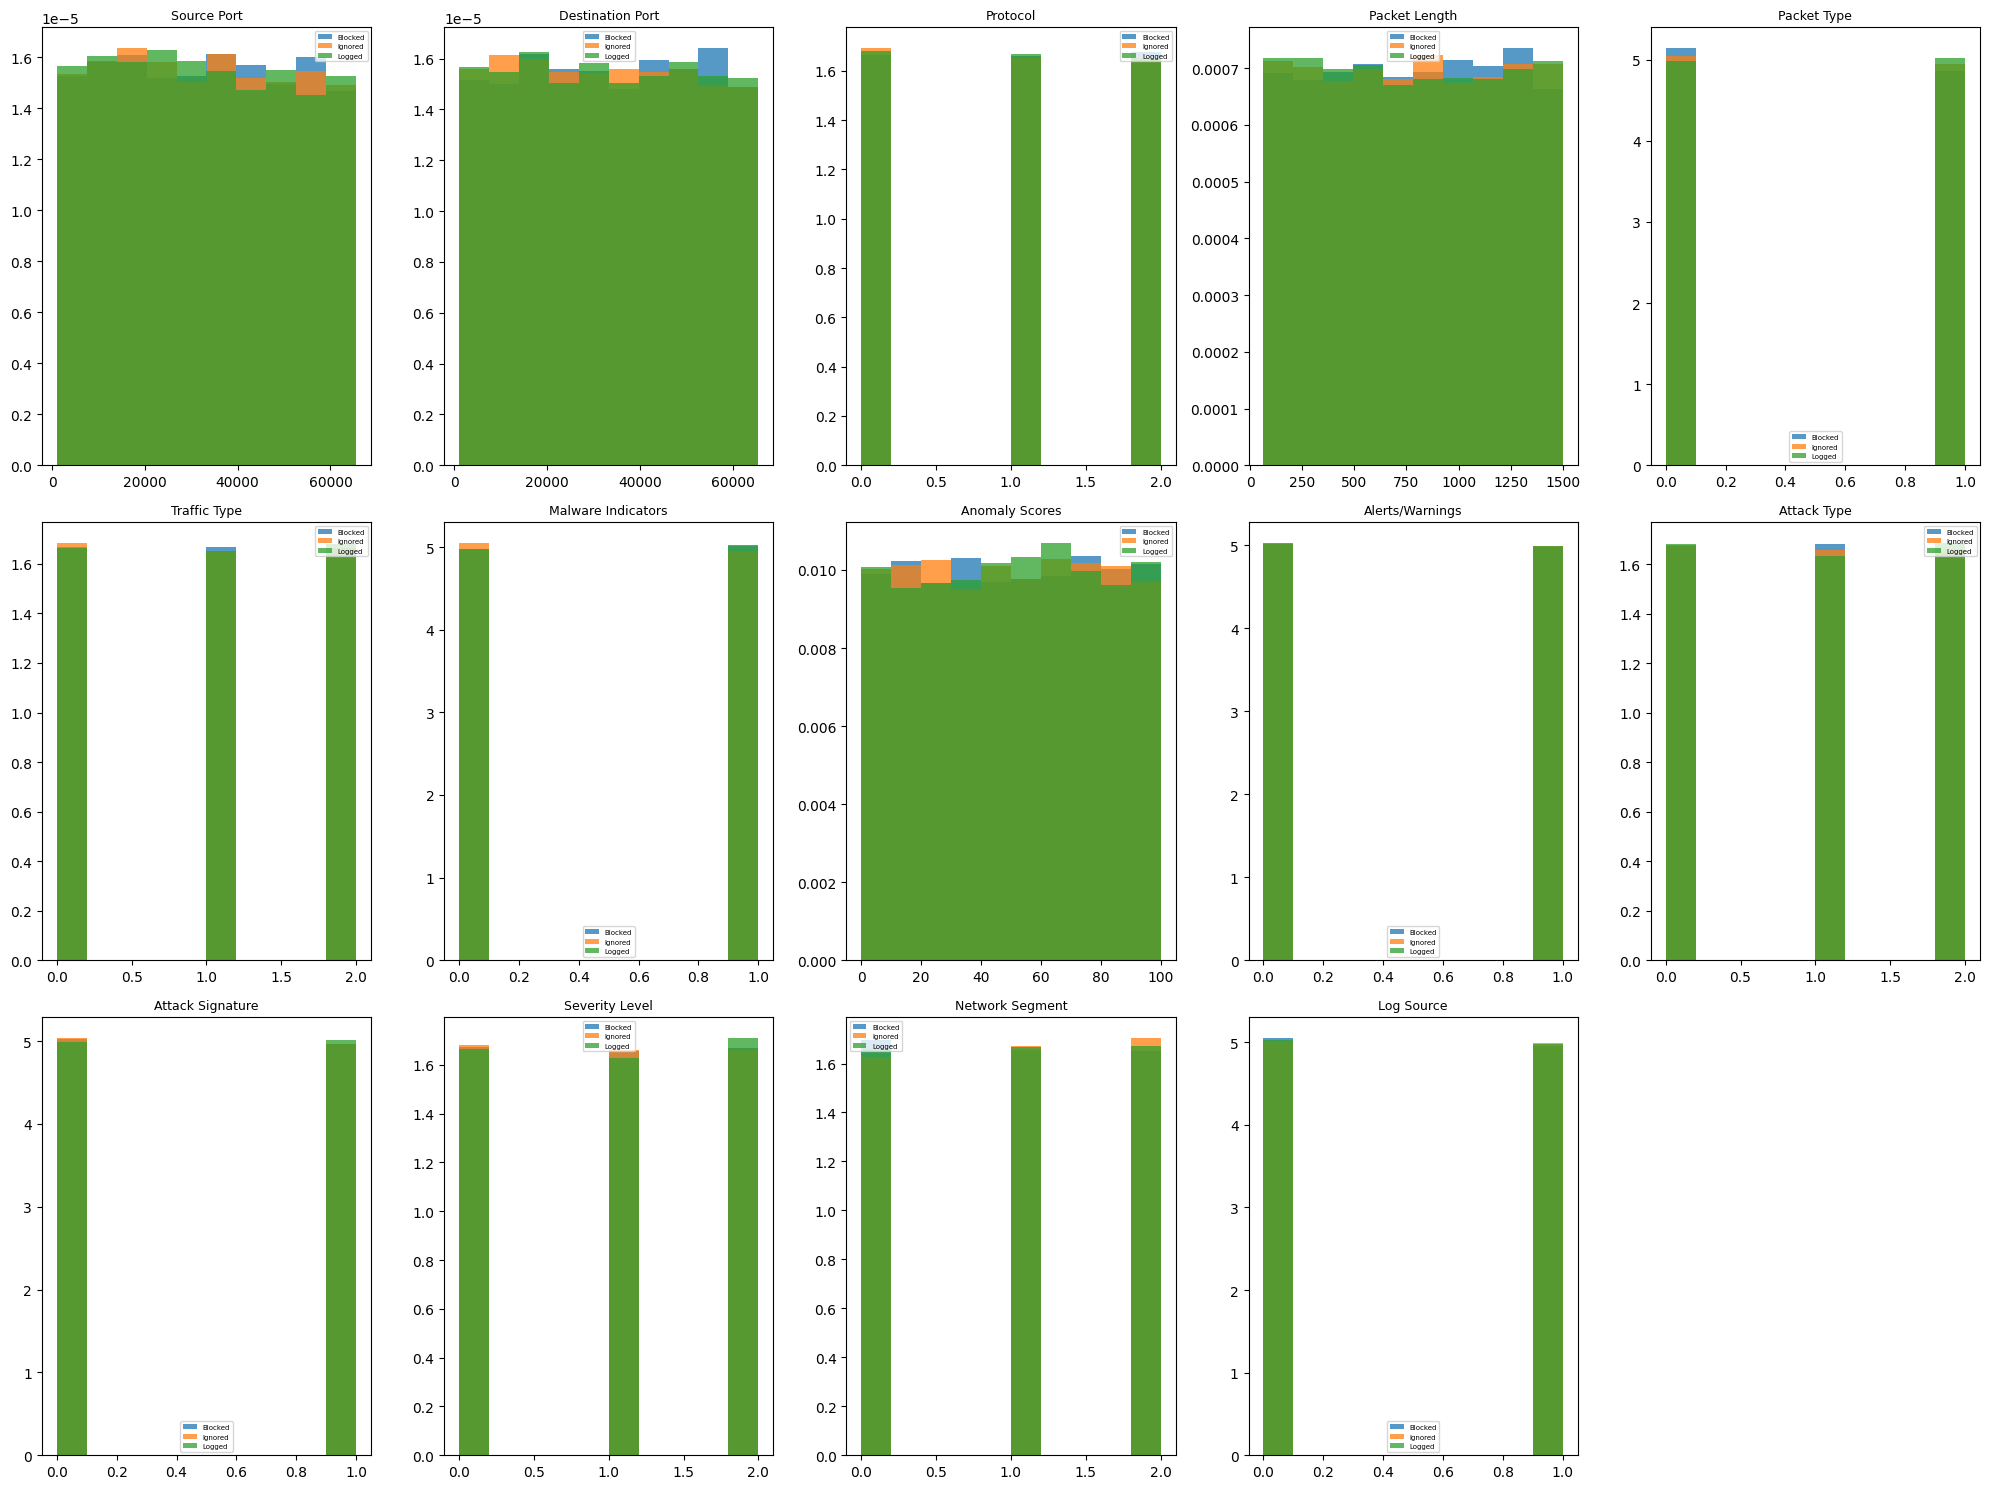

In [12]:
features = df.columns.drop(['Action Taken'])

plt.figure(figsize=(20,15))

idx_0 = df['Action Taken'] == 0
idx_1 = df['Action Taken'] == 1
idx_2 = df['Action Taken'] == 2

for i, feature in enumerate(features):
    plt.subplot(3, 5, i+1)
    plt.hist(df.loc[idx_0, feature], density=1, alpha=0.75, label='Blocked')
    plt.hist(df.loc[idx_1, feature], density=1, alpha=0.75, label='Ignored')
    plt.hist(df.loc[idx_2, feature], density=1, alpha=0.75, label='Logged')
    plt.legend(fontsize=5)
    plt.title(feature, fontsize=9)

plt.tight_layout()
plt.show()

Los histogramas muestran que en todas las columnas las tres clases se solapan 
completamente. No hay ninguna variable donde una clase se separe de las otras. 
Las columnas categóricas como Protocol, Traffic Type, Network Segment, Attack Type 
y Severity Level están distribuidas prácticamente al 33% exacto entre las tres clases. 
Esto ya me hace sospechar que va a ser difícil que un modelo aprenda algo útil, 
pero vamos a intentarlo igualmente.

## 5. Preparación de datos para el modelo

Separo las columnas que voy a usar para predecir (X) de la columna que quiero 
predecir (y). Luego divido los datos en train (80%) y test (20%) con stratify 
para que las tres clases mantengan la misma proporción. 

Para KNN y Regresión Logística hay que escalar los datos con StandardScaler 
porque son modelos que trabajan con distancias. Para los árboles y Random Forest 
no hace falta escalar, como dijo el profe en clase.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = df.columns.drop(['Action Taken'])
X = df[features].values
y = df['Action Taken'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

print('Datos train: ', X_train.shape)
print('Datos test:  ', X_test.shape)

scaler = StandardScaler().fit(X_train)
Xs_train = scaler.transform(X_train)
Xs_test = scaler.transform(X_test)

Datos train:  (32000, 14)
Datos test:   (8000, 14)


## 6. Modelado

Voy a entrenar cuatro modelos y compararlos: KNN, Regresión Logística, 
Árbol de Decisión y Random Forest. Para KNN y el Árbol uso GridSearchCV 
para buscar los mejores parámetros. Para Random Forest solo busco el 
mejor número de estimadores, que es lo que dijo el profe en clase.

KNN y Regresión Logística usan los datos escalados (Xs). Los árboles y 
Random Forest usan los datos sin escalar (X) porque no lo necesitan.

### 6.1 KNN

Fitting 5 folds for each of 19 candidates, totalling 95 fits
best mean cross-validation score: 0.340
best parameters: {'n_neighbors': 2}


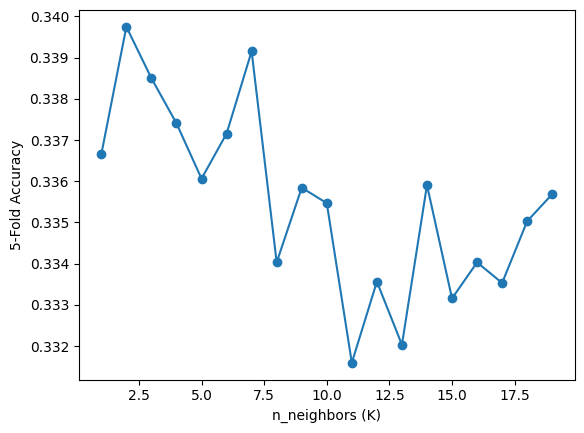

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': list(range(1, 20))}

grid_knn = GridSearchCV(KNeighborsClassifier(), scoring='accuracy', param_grid=param_grid, cv=5, verbose=1)
grid_knn.fit(Xs_train, y_train)

print("best mean cross-validation score: {:.3f}".format(grid_knn.best_score_))
print("best parameters: {}".format(grid_knn.best_params_))

scores = np.array(grid_knn.cv_results_['mean_test_score'])
plt.plot(list(range(1, 20)), scores, '-o')
plt.xlabel('n_neighbors (K)')
plt.ylabel('5-Fold Accuracy')
plt.show()

In [15]:
knnModel = KNeighborsClassifier(n_neighbors=grid_knn.best_params_['n_neighbors']).fit(Xs_train, y_train)

print("Train: ", knnModel.score(Xs_train, y_train))
print("Test: ", knnModel.score(Xs_test, y_test))

Train:  0.6669375
Test:  0.337625


### 6.2 Regresión Logística

In [16]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=1).fit(Xs_train, y_train)

print("Train: ", lr.score(Xs_train, y_train))
print("Test: ", lr.score(Xs_test, y_test))

Train:  0.3445625
Test:  0.33725


### 6.3 Árbol de Decisión

Fitting 5 folds for each of 19 candidates, totalling 95 fits
best mean cross-validation score: 0.339
best parameters: {'max_depth': 5}


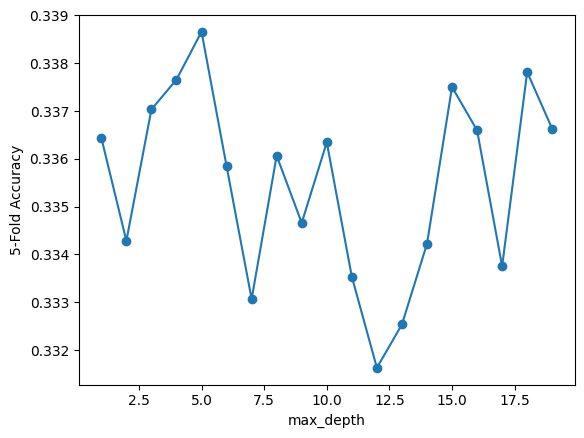

In [17]:
from sklearn.tree import DecisionTreeClassifier

max_depth_vector = list(range(1, 20))
param_grid = {'max_depth': max_depth_vector}

grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42), scoring='accuracy', param_grid=param_grid, cv=5, verbose=1)
grid_tree.fit(X_train, y_train)

print("best mean cross-validation score: {:.3f}".format(grid_tree.best_score_))
print("best parameters: {}".format(grid_tree.best_params_))

scores = np.array(grid_tree.cv_results_['mean_test_score'])
plt.plot(max_depth_vector, scores, '-o')
plt.xlabel('max_depth')
plt.ylabel('5-Fold Accuracy')
plt.show()

In [18]:
maxDepthOptimo = grid_tree.best_params_['max_depth']
treeModel = DecisionTreeClassifier(max_depth=maxDepthOptimo, random_state=42).fit(X_train, y_train)

print("Train: ", treeModel.score(X_train, y_train))
print("Test: ", treeModel.score(X_test, y_test))

Train:  0.3561875
Test:  0.33425


### 6.4 Random Forest

Para Random Forest lo único que hay que buscar 
con GridSearchCV es el número de estimadores (número de árboles). No hace 
falta tocar max_depth ni nada más.

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END ....................................n_estimators=10; total time=   0.2s
[CV] END ....................................n_estimators=10; total time=   0.2s
[CV] END ....................................n_estimators=10; total time=   0.2s
[CV] END ....................................n_estimators=20; total time=   0.5s
[CV] END ....................................n_estimators=20; total time=   0.5s
[CV] END ....................................n_estimators=20; total time=   0.5s
[CV] END ....................................n_estimators=30; total time=   0.8s
[CV] END ....................................n_estimators=30; total time=   0.8s
[CV] END ....................................n_estimators=30; total time=   0.8s
[CV] END ....................................n_estimators=40; total time=   1.1s
[CV] END ....................................n_estimators=40; total time=   1.1s
[CV] END ....................................n_e

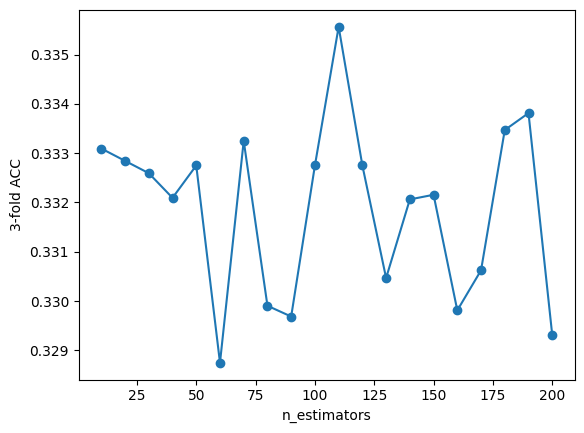

In [19]:
from sklearn.ensemble import RandomForestClassifier

n_estimators_range = list(range(10, 210, 10))
tuned_parameters = {'n_estimators': n_estimators_range}

grid_rf = GridSearchCV(RandomForestClassifier(), scoring='accuracy', param_grid=tuned_parameters, cv=3, verbose=2)
grid_rf.fit(X_train, y_train)

print("best mean cross-validation score: {:.3f}".format(grid_rf.best_score_))
print("best parameters: {}".format(grid_rf.best_params_))

scores = np.array(grid_rf.cv_results_['mean_test_score'])
plt.plot(n_estimators_range, scores, '-o')
plt.xlabel('n_estimators')
plt.ylabel('3-fold ACC')
plt.show()

In [20]:
n_estimators_optimo = grid_rf.best_params_['n_estimators']
randomForest = RandomForestClassifier(n_estimators=n_estimators_optimo).fit(X_train, y_train)

print("Train: ", randomForest.score(X_train, y_train))
print("Test: ", randomForest.score(X_test, y_test))

Train:  1.0
Test:  0.338125


## 7. Feature Importance del Random Forest

Le pido al Random Forest que me diga qué columnas le han parecido más 
importantes a la hora de intentar predecir. Esto nos ayuda a entender 
un poco mejor qué está pasando con los datos.

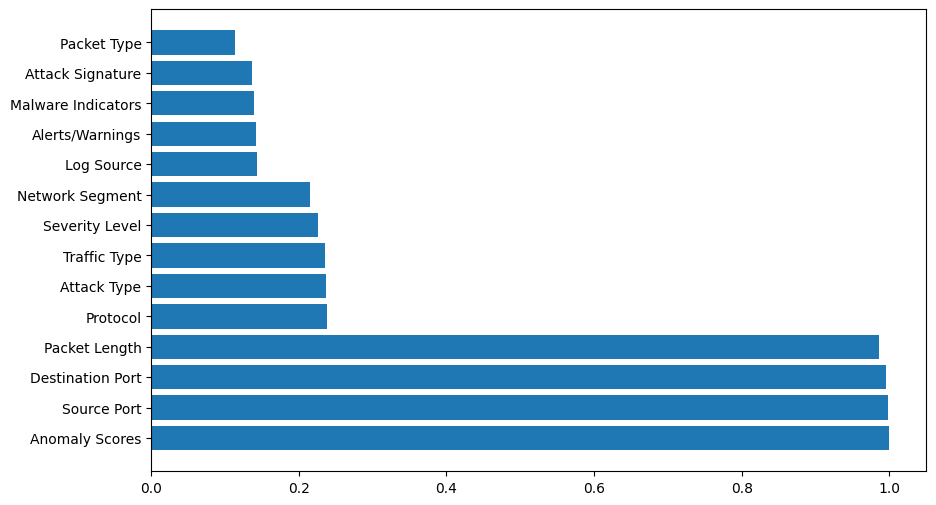

In [21]:
importances = randomForest.feature_importances_
importances = importances / np.max(importances)

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.barh(range(X_train.shape[1]), importances[indices])
plt.yticks(range(X_train.shape[1]), features[indices])
plt.show()

## 8. Evaluación

Miro la confusion matrix de los cuatro modelos para ver cómo están fallando.

In [22]:
from sklearn.metrics import confusion_matrix

y_pred_knn = knnModel.predict(Xs_test)
y_pred_lr = lr.predict(Xs_test)
y_pred_tree = treeModel.predict(X_test)
y_pred_rf = randomForest.predict(X_test)

print('--- KNN ---')
print(confusion_matrix(y_test, y_pred_knn))
print()
print('--- Regresion Logistica ---')
print(confusion_matrix(y_test, y_pred_lr))
print()
print('--- Arbol de Decision ---')
print(confusion_matrix(y_test, y_pred_tree))
print()
print('--- Random Forest ---')
print(confusion_matrix(y_test, y_pred_rf))

--- KNN ---
[[1514  901  291]
 [1494  885  276]
 [1460  877  302]]

--- Regresion Logistica ---
[[1390  658  658]
 [1324  663  668]
 [1325  669  645]]

--- Arbol de Decision ---
[[2099  153  454]
 [2070  154  431]
 [2053  165  421]]

--- Random Forest ---
[[964 898 844]
 [955 927 773]
 [947 878 814]]


## 9. Conclusión

El dataset que he usado tiene 40.000 filas, cada una es una incidencia de un 
ciberataque, y tiene 25 columnas con datos como la IP de origen, el puerto, 
el protocolo, el tipo de ataque, etc. Lo que tenía que predecir era la columna 
"Action Taken", que dice qué se hizo con ese ataque: bloquearlo (Blocked), 
ignorarlo (Ignored) o registrarlo (Logged). Como tenemos las respuestas correctas 
en los datos, es un problema de clasificación supervisada con 3 clases.

Lo primero que hice fue explorar los datos para entender con qué estaba trabajando. 
Vi que las tres clases están muy equilibradas, unas 13.300 muestras de cada una, 
así que no hay problema de desbalanceo y puedo usar accuracy para medir los modelos.

Luego miré si había outliers en las columnas numéricas y no encontré nada raro, 
los puertos están en rangos normales (1024-65535), el tamaño de paquete entre 64 y 
1500 bytes y el anomaly score entre 0 y 100. También miré la correlación entre las 
columnas numéricas con un heatmap y salió prácticamente cero en todas, no hay 
relación lineal entre ellas.

Para preparar los datos eliminé las columnas que no podía usar: las IPs porque 
tenían 40.000 valores distintos y eso es imposible de codificar, los timestamps, 
el texto del payload que era lorem ipsum (texto de prueba), los nombres de usuario, 
el device information y la geolocalización. También eliminé Proxy Information, 
Firewall Logs e IDS/IPS Alerts porque tenían casi la mitad de valores vacíos. 
Las columnas Malware Indicators y Alerts/Warnings también tenían nulos pero las 
convertí en 0 y 1 (tiene alerta o no tiene) porque esa información sí podía ser 
útil. El resto de columnas de texto las pasé a números con LabelEncoder.

Al pintar los histogramas por clase me di cuenta de algo importante: en todas las 
columnas las tres clases se solapan completamente. No hay ninguna columna donde 
una clase se separe de las otras. Las columnas categóricas como Protocol, Traffic 
Type, Network Segment, Attack Type y Severity Level están distribuidas 
prácticamente al 33% exacto entre Blocked, Ignored y Logged. Esto ya me hizo 
sospechar que iba a ser muy difícil que un modelo aprendiera algo, pero decidí 
probarlo igualmente.

Entrené cuatro modelos:

- KNN con GridSearchCV: el mejor K fue 2, con un accuracy en test de 0.338. 
  En train sacó 0.667, lo que significa que estaba haciendo overfitting, 
  memorizaba los datos de entrenamiento pero luego con datos nuevos no 
  funcionaba.

- Regresión Logística: accuracy en test de 0.337. En train sacó 0.345, o sea 
  que ni siquiera era capaz de memorizar los datos de entrenamiento. No había 
  ningún patrón lineal que encontrar.

- Árbol de Decisión con GridSearchCV: el mejor max_depth fue 5, con un accuracy 
  en test de 0.334. En train sacó 0.356, parecido al test, así que no hacía 
  overfitting pero tampoco aprendía nada.

- Random Forest con GridSearchCV: el mejor número de estimadores fue 60, con un 
  accuracy en test de 0.332. En train sacó 1.0 (100%), o sea que memorizó todos 
  los datos de entrenamiento pero luego en test solo acertaba el 33%. Overfitting 
  total.

Los cuatro modelos dan alrededor del 33% en test, que es exactamente lo mismo que 
acertaría alguien eligiendo al azar entre 3 opciones. Las confusion matrices lo 
confirman: ningún modelo consigue distinguir bien las tres clases.

También le pedí al Random Forest el feature importance para ver qué columnas 
consideraba más importantes. Las numéricas (Destination Port, Source Port, Packet 
Length, Anomaly Scores) salieron con la importancia más alta. Pero como explicó el 
profe en clase, el Random Forest sobreestima la importancia de columnas que tienen 
mucho ruido. Las columnas categóricas salieron todas con una importancia baja y 
parecida entre ellas, lo que confirma que ninguna aporta información útil.

Creo que el problema es que este dataset tiene los datos distribuidos de forma 
demasiado uniforme entre las tres clases. Da igual qué columna mires, siempre 
hay prácticamente un 33% de Blocked, un 33% de Ignored y un 33% de Logged. Es 
como si la decisión de qué hacer con cada ataque no dependiera de nada de lo que 
aparece en el dataset. Probablemente esa decisión depende de cosas que no están 
recogidas aquí, como las reglas internas del firewall, las políticas de seguridad 
de la empresa o el contexto específico en el que ocurrió cada ataque.

He seguido el proceso que hemos aprendido en clase: explorar los datos, 
preprocesarlos, entrenar varios modelos, comparar métricas y sacar conclusiones. 
Los resultados no han sido buenos en cuanto a accuracy, pero creo que eso no es 
un fallo del proceso sino de los datos en sí. Si este dataset tuviera columnas 
que realmente separaran las clases, los modelos habrían funcionado mucho mejor, 
como hemos visto en clase con otros datasets como el de cáncer o el de frutas.

## 10. Extra: Predecir Severity Level

El enunciado dice que predecir Severity Level no es obligatorio pero suma nota. 
Voy a repetir el mismo proceso para ver si pasa lo mismo que con Action Taken.

In [23]:
df2 = pd.read_csv('data/cybersecurity_attacks.csv')

columns_to_drop = ['Timestamp', 'Source IP Address', 'Destination IP Address',
                   'Payload Data', 'User Information', 'Device Information',
                   'Geo-location Data', 'Proxy Information', 'Firewall Logs',
                   'IDS/IPS Alerts']

df2 = df2.drop(columns_to_drop, axis=1)

df2['Malware Indicators'] = df2['Malware Indicators'].apply(lambda x: 0 if pd.isnull(x) else 1)
df2['Alerts/Warnings'] = df2['Alerts/Warnings'].apply(lambda x: 0 if pd.isnull(x) else 1)

df2.head().T

,0,1,2,3,4
Source Port,31225,17245,16811,20018,6131
Destination Port,17616,48166,53600,32534,26646
Protocol,ICMP,ICMP,UDP,UDP,TCP
Packet Length,503,1174,306,385,1462
Packet Type,Data,Data,Control,Data,Data
Traffic Type,HTTP,HTTP,HTTP,HTTP,DNS
Malware Indicators,1,1,1,0,0
Anomaly Scores,28.67,51.5,87.42,15.79,0.52
Alerts/Warnings,0,0,1,1,1
Attack Type,Malware,Malware,DDoS,Malware,DDoS


In [24]:
le2_protocol = LabelEncoder()
le2_packet = LabelEncoder()
le2_traffic = LabelEncoder()
le2_attack = LabelEncoder()
le2_action = LabelEncoder()
le2_severity = LabelEncoder()
le2_network = LabelEncoder()
le2_signature = LabelEncoder()
le2_log = LabelEncoder()

df2['Protocol'] = le2_protocol.fit_transform(df2['Protocol'])
df2['Packet Type'] = le2_packet.fit_transform(df2['Packet Type'])
df2['Traffic Type'] = le2_traffic.fit_transform(df2['Traffic Type'])
df2['Attack Type'] = le2_attack.fit_transform(df2['Attack Type'])
df2['Action Taken'] = le2_action.fit_transform(df2['Action Taken'])
df2['Severity Level'] = le2_severity.fit_transform(df2['Severity Level'])
df2['Network Segment'] = le2_network.fit_transform(df2['Network Segment'])
df2['Attack Signature'] = le2_signature.fit_transform(df2['Attack Signature'])
df2['Log Source'] = le2_log.fit_transform(df2['Log Source'])

print(list(le2_severity.classes_))

['High', 'Low', 'Medium']


In [25]:
features2 = df2.columns.drop(['Severity Level'])
X2 = df2[features2].values
y2 = df2['Severity Level'].values

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=0, stratify=y2)

print('Datos train: ', X2_train.shape)
print('Datos test:  ', X2_test.shape)

Datos train:  (32000, 14)
Datos test:   (8000, 14)


In [26]:
grid_rf2 = GridSearchCV(RandomForestClassifier(), scoring='accuracy', param_grid={'n_estimators': list(range(10, 210, 10))}, cv=3, verbose=1)
grid_rf2.fit(X2_train, y2_train)

print("best mean cross-validation score: {:.3f}".format(grid_rf2.best_score_))
print("best parameters: {}".format(grid_rf2.best_params_))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
best mean cross-validation score: 0.337
best parameters: {'n_estimators': 190}


In [27]:
rf2 = RandomForestClassifier(n_estimators=grid_rf2.best_params_['n_estimators']).fit(X2_train, y2_train)

print("Train: ", rf2.score(X2_train, y2_train))
print("Test: ", rf2.score(X2_test, y2_test))

Train:  1.0
Test:  0.331


Pasa exactamente lo mismo que con Action Taken. El Random Forest memoriza 
todo en train (100%) pero en test saca un 33%, que es lo mismo que el azar. 
Severity Level también está distribuido de forma uniforme entre las tres 
clases y los modelos no pueden predecirlo. No tiene sentido seguir probando 
con Attack Type porque seguramente va a pasar lo mismo, ya que en los 
histogramas se veía que también estaba al 33% exacto.

## 11. Extra: Classification Report

Saco el classification report de los cuatro modelos para ver precision, 
recall y F1 de cada uno, no solo el accuracy.

In [28]:
from sklearn.metrics import classification_report

print('--- KNN ---')
print(classification_report(y_test, y_pred_knn))

print('--- Regresion Logistica ---')
print(classification_report(y_test, y_pred_lr))

print('--- Arbol de Decision ---')
print(classification_report(y_test, y_pred_tree))

print('--- Random Forest ---')
print(classification_report(y_test, y_pred_rf))

--- KNN ---
              precision    recall  f1-score   support

           0       0.34      0.56      0.42      2706
           1       0.33      0.33      0.33      2655
           2       0.35      0.11      0.17      2639

    accuracy                           0.34      8000
   macro avg       0.34      0.34      0.31      8000
weighted avg       0.34      0.34      0.31      8000

--- Regresion Logistica ---
              precision    recall  f1-score   support

           0       0.34      0.51      0.41      2706
           1       0.33      0.25      0.29      2655
           2       0.33      0.24      0.28      2639

    accuracy                           0.34      8000
   macro avg       0.33      0.34      0.33      8000
weighted avg       0.33      0.34      0.33      8000

--- Arbol de Decision ---
              precision    recall  f1-score   support

           0       0.34      0.78      0.47      2706
           1       0.33      0.06      0.10      2655
         

## 12. Extra: Visualización del Árbol de Decisión

Pinto el árbol de decisión para ver cómo ha ido dividiendo los datos 
y qué columnas ha usado para tomar las decisiones.

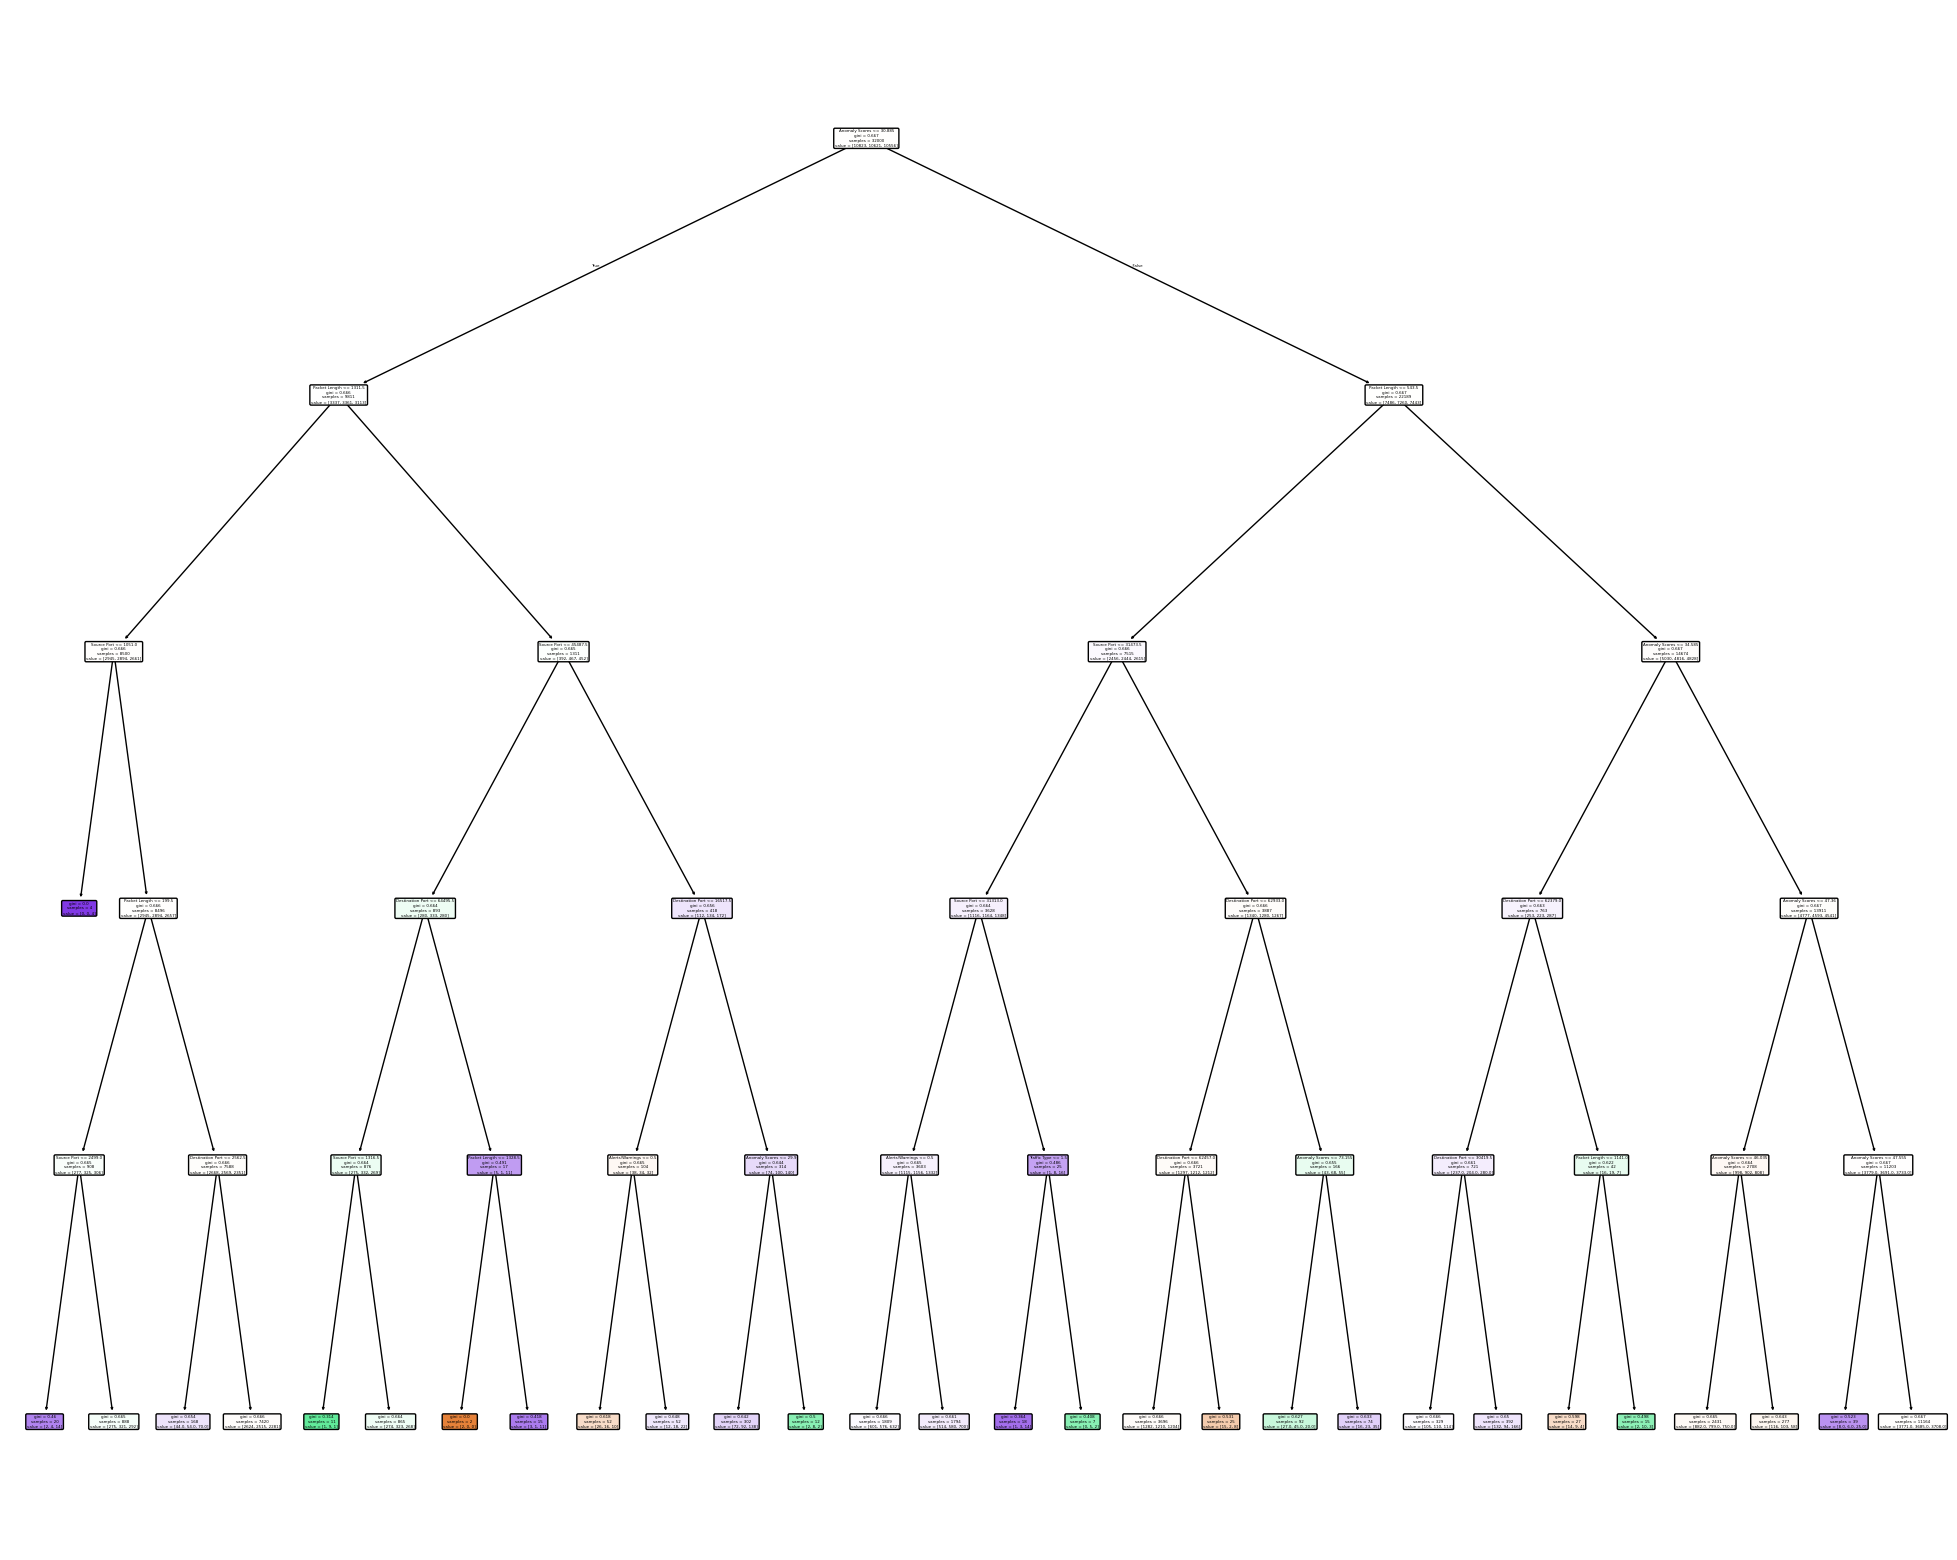

In [30]:
from sklearn import tree

fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(treeModel, feature_names=features, filled=True, rounded=True)

## 13. Conclusión final

Voy a intentar explicar todo lo que he hecho en esta práctica y lo que he 
sacado en claro de los resultados.

El dataset que nos dieron tiene 40.000 filas de incidencias de ciberataques 
y 25 columnas. Cada fila es un ataque que se ha registrado en un sistema y 
tiene datos como la IP de origen, la IP de destino, el puerto, el protocolo, 
el tipo de tráfico, si saltó alguna alerta, el tipo de ataque y cosas así. 
Lo que yo tenía que hacer era predecir la columna "Action Taken" que dice qué 
se hizo con cada ataque: bloquearlo (Blocked), ignorarlo (Ignored) o dejarlo 
registrado (Logged). Como ya tenemos esas respuestas en los datos estamos 
ante un problema de clasificación supervisada con 3 clases.

### Exploración de datos

Lo primero que hice fue cargar el dataset y echarle un vistazo general con 
head, dtypes, describe y todo eso. Me encontré con que de las 25 columnas 
solo 4 eran numéricas (Source Port, Destination Port, Packet Length y Anomaly 
Scores) y el resto eran texto. También había 5 columnas con valores nulos: 
Malware Indicators, Alerts/Warnings, Proxy Information, Firewall Logs e 
IDS/IPS Alerts.

Lo que sí me llamó la atención desde el principio es que al hacer el 
value_counts de Action Taken, las tres clases tenían casi exactamente el 
mismo número de filas: unas 13.300 cada una. Están perfectamente equilibradas, 
así que no hay desbalanceo y puedo usar accuracy para medir los modelos.

### Outliers y correlación

Revisé las columnas numéricas con el describe para ver si había valores raros 
y no encontré nada fuera de lo normal. Los puertos van de 1024 a 65535 que es 
el rango normal, el tamaño de paquete de 64 a 1500 bytes y el anomaly score 
de 0 a 100. Todo tiene sentido.

Hice un heatmap de correlación con seaborn y salió todo amarillo. Correlación 
prácticamente cero entre todas las columnas numéricas. Eso ya era una señal 
de que iba a ser complicado porque si las columnas no tienen relación entre 
ellas es más difícil que un modelo encuentre patrones.

### Preprocesamiento

Aquí tuve que tomar varias decisiones sobre qué columnas quitar y cuáles 
dejar. Las IPs (Source y Destination) tenían 40.000 valores distintos cada 
una, básicamente un valor por fila, así que no sirven para nada. Los 
timestamps igual, todos diferentes. El Payload Data era texto en latín de 
prueba (lorem ipsum), ahí no hay información de ningún tipo. Los nombres 
de usuario, el device information y la geolocalización tenían miles de 
valores distintos, imposible de codificar.

También quité Proxy Information, Firewall Logs e IDS/IPS Alerts porque 
tenían casi la mitad de datos vacíos y además los pocos valores que había 
eran todos iguales (por ejemplo Firewall Logs solo tenía "Log Data" en 
las 20.000 filas que no eran nulas).

Las columnas Malware Indicators y Alerts/Warnings también tenían nulos 
pero las traté diferente: en vez de quitarlas las convertí en 0 y 1. Si 
tenía un valor le puse 1, si era nulo le puse 0. Así al menos conservo 
la información de "tiene alerta" o "no tiene alerta".

Las columnas de texto que me quedaron (Protocol, Packet Type, Traffic Type, 
Attack Type, Attack Signature, Severity Level, Network Segment y Log Source) 
las convertí a números con LabelEncoder para que los modelos pudieran 
trabajar con ellas.

### Histogramas por clase

Esta parte fue la más reveladora de toda la práctica. Pinté los histogramas 
de cada columna separados por las tres clases (Blocked, Ignored, Logged) 
esperando ver que al menos alguna columna mostrara diferencias entre las 
clases. Pero no. En todas las columnas las tres clases se solapan 
completamente.

Lo más llamativo es que las columnas categóricas como Protocol, Traffic 
Type, Attack Type, Severity Level y Network Segment están distribuidas 
prácticamente al 33% exacto entre las tres clases. Es decir, da igual 
que el protocolo sea ICMP, UDP o TCP, siempre hay la misma proporción 
de Blocked, Ignored y Logged. Lo mismo con el tipo de ataque, con la 
severidad, con todo. Es como si la acción se hubiera asignado tirando 
un dado.

Ya en este punto sospechaba que iba a ser muy difícil que ningún modelo 
aprendiera algo útil, pero decidí probarlo igualmente.

### Preparación para el modelo

Separé las columnas que usaba para predecir (X) de la columna objetivo (y). 
Hice el train/test split con 80% para entrenar y 20% para testear, usando 
stratify para mantener la proporción de las tres clases y random_state para 
que los resultados fueran reproducibles.

Como iba a usar KNN y Regresión Logística, que son modelos que trabajan con 
distancias, escalé los datos con StandardScaler. Para el Árbol de Decisión 
y el Random Forest no hice el escalado porque esos modelos no lo necesitan, 
trabajan haciendo divisiones y les da igual la escala de los datos.

### Modelos y resultados

Entrené cuatro modelos:

KNN: Le busqué el mejor K con GridSearchCV y salió K=2. La gráfica del 
GridSearchCV iba subiendo y bajando sin un patrón claro, lo que ya daba 
mala señal. En train sacó 0.667 pero en test solo 0.338. Hay bastante 
overfitting. Con K=2 el modelo solo mira los 2 vecinos más cercanos y 
por eso memoriza tanto los datos de entrenamiento, pero luego con datos 
nuevos no le sirve de nada.

Regresión Logística: Sacó 0.345 en train y 0.337 en test. Los dos 
números son casi iguales así que no hay overfitting, pero tampoco aprende 
nada. Es que no hay ningún patrón lineal en estos datos que pueda 
encontrar.

Árbol de Decisión: Con GridSearchCV el mejor max_depth fue 5. En train 
0.356 y en test 0.334. La gráfica del GridSearchCV también subía y bajaba 
sin sentido, da igual la profundidad que le pongas. Al pintar el árbol 
visualmente se ve que las hojas de abajo tienen colores mezclados, lo que 
significa que no consigue separar bien las clases en ninguna rama.

Random Forest: Con GridSearchCV buscando solo el número de estimadores 
salió 60 como mejor. Y aquí me llevé la mayor sorpresa: en train sacó 
1.0, o sea el 100%, memoriza absolutamente todo. Pero en test solo 0.332. 
Es el overfitting más extremo de los cuatro modelos. El Random Forest es 
tan potente que puede memorizar cualquier dato pero si no hay un patrón 
real que aprender pues luego con datos nuevos no sirve.

Los cuatro modelos dan alrededor del 33% en test. Eso es exactamente lo 
que acertaría alguien eligiendo al azar entre 3 opciones sin mirar nada.

### Feature importance

Le pedí al Random Forest la importancia de las variables para ver si 
alguna columna destacaba. Las numéricas (Destination Port, Source Port, 
Packet Length, Anomaly Scores) salieron con importancia alta, casi al 
100%. Pero hay que tener cuidado con esto: el Random Forest tiende a 
darle mucha importancia a columnas con muchos valores distintos aunque 
sean ruido. Como los puertos tienen miles de valores diferentes el modelo 
las usa mucho para hacer sus divisiones internas, pero eso no significa 
que contengan información útil para predecir. Las columnas categóricas 
salieron todas con importancia baja y parecida entre ellas, confirmando 
que ninguna aporta nada.

### Evaluación

Las confusion matrices de los cuatro modelos muestran que ninguno 
distingue bien las clases. Cada modelo falla de forma diferente: el KNN 
y el Árbol tienden a predecir mucho la clase 0 (Blocked), la Regresión 
Logística reparte un poco más y el Random Forest es el que más equilibra 
pero sin acertar.

El classification report confirma lo mismo: precision, recall y F1 están 
todos alrededor de 0.33-0.34 para todos los modelos. No hay ninguno que 
destaque en ninguna métrica.

### Severity Level

Probé también a predecir Severity Level que era una de las columnas 
opcionales del enunciado. Repetí todo el proceso y el resultado fue 
exactamente igual: el Random Forest sacó 100% en train y 33% en test. 
Mismo problema, la columna Severity Level también está distribuida al 
33% exacto entre sus tres clases (High, Low, Medium). No tiene sentido 
probar con Attack Type porque en los histogramas ya se veía que también 
estaba al 33%.

### Mi opinión sobre lo que ha pasado

Al principio me frustré bastante porque veía que todo daba 33% y pensaba 
que estaba haciendo algo mal. Pero después de analizar los datos a fondo, 
ver los histogramas, probar cuatro modelos diferentes, mirar el feature 
importance y comprobar que con Severity Level pasa lo mismo, creo que 
tengo claro lo que ocurre.

El problema no está en el proceso que he seguido ni en los modelos que 
he usado. El problema está en los datos. Todas las columnas del dataset 
están distribuidas de forma casi perfecta al 33% entre las tres clases. 
No hay ninguna columna donde se note una diferencia entre Blocked, 
Ignored y Logged. Es como si los datos se hubieran generado de forma 
aleatoria o sintética.

En clase hemos trabajado con otros datasets como el de cáncer o el de 
frutas donde los modelos sacaban 90% o más porque ahí sí había columnas 
que separaban las clases. En este dataset eso no existe. La decisión de 
bloquear, ignorar o registrar un ataque probablemente depende de cosas 
que no están recogidas aquí, como las reglas internas del firewall, las 
políticas de seguridad de la empresa o el contexto del momento en que 
ocurrió cada ataque.

He seguido todo el proceso que hemos aprendido: explorar los datos, 
limpiarlos, preprocesarlos, visualizar con histogramas y heatmaps, 
entrenar varios modelos con GridSearchCV, comparar métricas, mirar 
las confusion matrices, el classification report y el feature importance. 
Los resultados no han sido buenos en cuanto a accuracy pero creo que eso 
es precisamente lo que hay que saber reconocer: a veces los datos no 
tienen la información que necesitas y no hay modelo que lo arregle.